# 04 · Vision Tower Anatomy: Patches, 2D RoPE, Pooling

**Hardware**: 🟢 CPU, zero downloads. A miniature tower with random weights — the arithmetic and the shapes are the subject.

## What you will do

1. Trace an image through all four stages and print the shape at each
2. Reimplement `apply_multidimensional_rope` and `assert_close` it
3. Verify each axis gets its **own full frequency spectrum**, not half of a shared one
4. Prove the pooler assigns patches to soft tokens by 3×3 **spatial block**, not by sequence index
5. Watch `clamp(min=0)` handle the `(-1, -1)` padding sentinel

In [1]:
%pip install -q "transformers>=5.14" torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import Gemma4VisionConfig
from transformers.models.gemma4.modeling_gemma4 import (
    Gemma4VisionModel, apply_multidimensional_rope, rotate_half,
)
from transformers.models.gemma4.image_processing_gemma4 import Gemma4ImageProcessor

torch.manual_seed(0)

config = Gemma4VisionConfig(
    hidden_size=64, intermediate_size=128, num_hidden_layers=2,
    num_attention_heads=4, num_key_value_heads=4, head_dim=16,
    patch_size=16, pooling_kernel_size=3, position_embedding_size=1024,
)
config._attn_implementation = "eager"
tower = Gemma4VisionModel(config).eval()
print(tower.__class__.__name__, "|", sum(p.numel() for p in tower.parameters()) / 1e6, "M params")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gemma4VisionModel | 0.26272 M params


## 1. Shapes through the tower

In [3]:
from PIL import Image

image = Image.fromarray(np.random.randint(0, 256, (240, 320, 3), dtype=np.uint8))
enc = Gemma4ImageProcessor(max_soft_tokens=70)([image], return_tensors="pt")
pixel_values, position_ids = enc["pixel_values"], enc["image_position_ids"]

captured = {}
def hook(name):
    def fn(mod, args, output):
        t = output[0] if isinstance(output, tuple) else getattr(output, "last_hidden_state", output)
        if torch.is_tensor(t):
            captured[name] = tuple(t.shape)
    return fn

handles = [
    tower.patch_embedder.register_forward_hook(hook("1 patch_embedder")),
    tower.encoder.register_forward_hook(hook("2 encoder")),
    tower.pooler.register_forward_hook(hook("3 pooler")),
]
with torch.no_grad():
    out = tower(pixel_values=pixel_values, pixel_position_ids=position_ids)
for h in handles:
    h.remove()

print(f"  0 pixel_values      {tuple(pixel_values.shape)}   <- fixed shape, padded (chapter 03)")
for k in sorted(captured):
    print(f"  {k:20s}{captured[k]}")
print(f"  4 after padding strip {tuple(out.last_hidden_state.shape)}   <- only real soft tokens survive")
print(f"\nreal soft tokens: {int(enc['num_soft_tokens_per_image'][0])}")

  0 pixel_values      (1, 630, 768)   <- fixed shape, padded (chapter 03)
  1 patch_embedder    (1, 630, 64)
  2 encoder           (1, 630, 64)
  3 pooler            (1, 70, 64)
  4 after padding strip (63, 64)   <- only real soft tokens survive

real soft tokens: 63


The padded slots are carried all the way through the encoder and then dropped by `hidden_states[pooler_mask]`. Fixed shapes in, variable content out.

## 2. The patch embedder

Two position signals, added to the same stream.

In [4]:
pe = tower.patch_embedder
print("input_proj :", pe.input_proj, f"  <- 3 * {config.patch_size}^2 = {3*config.patch_size**2}")
print("position_embedding_table:", tuple(pe.position_embedding_table.shape),
      "  <- (2 axes, position_embedding_size, hidden_size)")

print(f'''
forward() is four lines:

    pixel_values = 2 * (pixel_values - 0.5)      # [0,1] -> [-1,1]  <- chapter 03's missing normalisation
    hidden_states = self.input_proj(pixel_values)
    position_embeddings = self._position_embeddings(pixel_position_ids, padding_positions)
    return hidden_states + position_embeddings
''')

# the padding sentinel, handled by clamp-then-mask
pad = (position_ids == -1).all(dim=-1)
print("padding slots:", int(pad.sum()), "of", pad.shape[1])
clamped = position_ids.clamp(min=0)
print("min position id before clamp:", int(position_ids.min()), "after:", int(clamped.min()))
print("-> the gather must be valid even for entries about to be zeroed.")

input_proj : Linear(in_features=768, out_features=64, bias=False)   <- 3 * 16^2 = 768
position_embedding_table: (2, 1024, 64)   <- (2 axes, position_embedding_size, hidden_size)

forward() is four lines:

    pixel_values = 2 * (pixel_values - 0.5)      # [0,1] -> [-1,1]  <- chapter 03's missing normalisation
    hidden_states = self.input_proj(pixel_values)
    position_embeddings = self._position_embeddings(pixel_position_ids, padding_positions)
    return hidden_states + position_embeddings

padding slots: 63 of 630
min position id before clamp: -1 after: 0
-> the gather must be valid even for entries about to be zeroed.


## 3. 2D RoPE, by hand

The subtlety is in `compute_default_rope_parameters`, whose comment warns you off the obvious implementation:

> The reference implementation computes RoPE frequencies **INDEPENDENTLY** for each spatial dimension using the partitioned `head_dim` (`head_dim // ndim`), so both x and y dimensions get identical frequency ranges. This is different from splitting the global `inv_freq` between dimensions.

In [5]:
rope = tower.encoder.rotary_emb

base = config.rope_parameters["rope_theta"]
spatial_dim = config.head_dim // 2
mine_inv = 1.0 / (base ** (torch.arange(0, spatial_dim, 2, dtype=torch.float) / spatial_dim))

torch.testing.assert_close(rope.inv_freq, mine_inv)
print(f"inv_freq matches ✓   shape {tuple(mine_inv.shape)}, theta = {base}")
print(f"\nhead_dim = {config.head_dim}, so spatial_dim = head_dim // 2 = {spatial_dim}")
print("Each axis rotates its own half of the head with the SAME frequency range,")
print("so horizontal and vertical distance are directly comparable.")

wrong = 1.0 / (base ** (torch.arange(0, config.head_dim, 2, dtype=torch.float) / config.head_dim))
print(f"\nthe tempting-but-wrong version (full head_dim): {wrong.shape} -> would give")
print("x and y different frequency bands.")

inv_freq matches ✓   shape (4,), theta = 100.0

head_dim = 16, so spatial_dim = head_dim // 2 = 8
Each axis rotates its own half of the head with the SAME frequency range,
so horizontal and vertical distance are directly comparable.

the tempting-but-wrong version (full head_dim): torch.Size([8]) -> would give
x and y different frequency bands.


In [6]:
def my_apply_multidimensional_rope(x, cos, sin, position_ids, unsqueeze_dim=2):
    ndim = position_ids.shape[-1]
    num_input_channels = x.shape[-1]
    per_dim = 2 * (num_input_channels // (2 * ndim))

    x_parts = torch.split(x, [per_dim] * ndim, dim=-1)
    cos_parts = torch.split(cos, [per_dim] * ndim, dim=-1)
    sin_parts = torch.split(sin, [per_dim] * ndim, dim=-1)

    out = []
    for k in range(ndim):
        c = cos_parts[k].unsqueeze(unsqueeze_dim)
        s = sin_parts[k].unsqueeze(unsqueeze_dim)
        out.append(x_parts[k] * c + rotate_half(x_parts[k]) * s)
    return torch.cat(out, dim=-1)


nx, ny = 6, 4
pos = torch.tensor([[[x, y] for y in range(ny) for x in range(nx)]])
q = torch.randn(1, nx * ny, config.num_attention_heads, config.head_dim)
cos, sin = rope(q, pos)

lib = apply_multidimensional_rope(q, cos, sin, pos, unsqueeze_dim=2)
mine = my_apply_multidimensional_rope(q, cos, sin, pos)
torch.testing.assert_close(lib, mine)

print("2D RoPE matches the library ✓")
print(f"cos/sin: {tuple(cos.shape)}  (head_dim, split {config.head_dim//2} for x + {config.head_dim//2} for y)")
print(f"rotated: {tuple(lib.shape)}")

2D RoPE matches the library ✓
cos/sin: (1, 24, 16)  (head_dim, split 8 for x + 8 for y)
rotated: (1, 24, 4, 16)


In [7]:
# Relative position is what RoPE encodes: the dot product should depend on (dx, dy) only.
def rotated_dot(p1, p2):
    v = torch.ones(1, 2, config.num_attention_heads, config.head_dim)
    pp = torch.tensor([[p1, p2]])
    c, s = rope(v, pp)
    r = apply_multidimensional_rope(v, c, s, pp, unsqueeze_dim=2)
    return float((r[0, 0, 0] * r[0, 1, 0]).sum())

pairs = [((0, 0), (2, 0)), ((5, 3), (7, 3)),          # same dx=2, dy=0
         ((0, 0), (0, 2)), ((4, 1), (4, 3))]          # same dx=0, dy=2
for a, b in pairs:
    print(f"  {a} . {b}  (dx={b[0]-a[0]}, dy={b[1]-a[1]})  ->  {rotated_dot(a, b):+.4f}")
print("\nPairs with the same offset give the same score regardless of absolute position.")
print("That is the whole point of a rotary encoding — and it now works in two axes.")

  (0, 0) . (2, 0)  (dx=2, dy=0)  ->  +12.7370
  (5, 3) . (7, 3)  (dx=2, dy=0)  ->  +12.7370
  (0, 0) . (0, 2)  (dx=0, dy=2)  ->  +12.7370
  (4, 1) . (4, 3)  (dx=0, dy=2)  ->  +12.7370

Pairs with the same offset give the same score regardless of absolute position.
That is the whole point of a rotary encoding — and it now works in two axes.


## 4. The pooler is spatial, not sequential

`_avg_pool_by_positions` builds the pooling operation as a one-hot matmul driven by patch coordinates. Prove it assigns by 3×3 block.

In [8]:
nx, ny = 6, 3                                   # 18 patches -> 2 soft tokens
pos = torch.tensor([[[x, y] for y in range(ny) for x in range(nx)]])
# make each patch's features equal to its own index, so the mean is checkable by hand
h = torch.arange(nx * ny, dtype=torch.float32)[None, :, None].repeat(1, 1, config.hidden_size)
padding = torch.zeros(1, nx * ny, dtype=torch.bool)

pooled, mask = tower.pooler(h, pos, padding, output_length=(nx * ny) // 9)
scale = config.hidden_size ** 0.5               # the pooler also multiplies by sqrt(hidden_size)

print(f"in  {tuple(h.shape)}  ->  out {tuple(pooled.shape)}   (9 patches per soft token)")
for t in range(pooled.shape[1]):
    print(f"  soft token {t}: mean patch index = {pooled[0, t, 0].item() / scale:.1f}")

k = config.pooling_kernel_size
max_x = pos[..., 0].max() + 1
kernel_idx = torch.div(pos, k, rounding_mode="floor")
kernel_idx = kernel_idx[..., 0] + (max_x // k) * kernel_idx[..., 1]
for t in range(2):
    members = (kernel_idx[0] == t).nonzero().flatten().tolist()
    print(f"  soft token {t} <- patches {members}")

in  (1, 18, 64)  ->  out (1, 2, 64)   (9 patches per soft token)
  soft token 0: mean patch index = 7.0
  soft token 1: mean patch index = 10.0
  soft token 0 <- patches [0, 1, 2, 6, 7, 8, 12, 13, 14]
  soft token 1 <- patches [3, 4, 5, 9, 10, 11, 15, 16, 17]


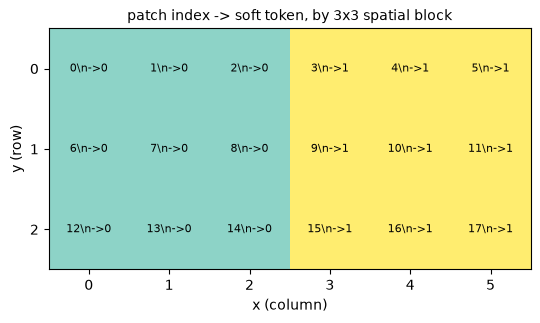

Contiguous in SPACE, not in sequence: token 0 takes columns 0-2 across all
three rows, which are patch indices 0,1,2, 6,7,8, 12,13,14.
A naive reshape-and-mean would have taken 0-8 instead.


In [9]:
fig, ax = plt.subplots(figsize=(6, 3.2))
grid = kernel_idx[0].reshape(ny, nx).numpy()
ax.imshow(grid, cmap="Set3", interpolation="nearest")
for y in range(ny):
    for x in range(nx):
        ax.text(x, y, f"{y*nx+x}\\n->{grid[y, x]}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(nx)); ax.set_yticks(range(ny))
ax.set_xlabel("x (column)"); ax.set_ylabel("y (row)")
ax.set_title("patch index -> soft token, by 3x3 spatial block", fontsize=10)
plt.tight_layout(); plt.show()

print("Contiguous in SPACE, not in sequence: token 0 takes columns 0-2 across all")
print("three rows, which are patch indices 0,1,2, 6,7,8, 12,13,14.")
print("A naive reshape-and-mean would have taken 0-8 instead.")

## 5. The float32 escape hatch

Multiplying by `sqrt(hidden_size)` can overflow fp16, so the pooler computes and returns float32 regardless of the model's dtype.

In [10]:
print("root_hidden_size =", tower.pooler.root_hidden_size, f"= sqrt({config.hidden_size})")
print("pooled dtype     =", pooled.dtype)
print(f"\nAt Gemma 4's real vision widths: sqrt(768) = {768**0.5:.1f}, sqrt(1152) = {1152**0.5:.1f}")
print(f"fp16 max is 65504 — activations only need to reach {65504/1152**0.5:.0f} before that overflows.")
print("This is the class of bug that is nearly impossible to find from a loss curve.")

root_hidden_size = 8.0 = sqrt(64)
pooled dtype     = torch.float32

At Gemma 4's real vision widths: sqrt(768) = 27.7, sqrt(1152) = 33.9
fp16 max is 65504 — activations only need to reach 1930 before that overflows.
This is the class of bug that is nearly impossible to find from a loss curve.


## 6. The connector

After all of the above, the bridge into the language model is the most boring module in the file.

In [11]:
from transformers import Gemma4TextConfig
from transformers.models.gemma4.modeling_gemma4 import Gemma4MultimodalEmbedder

text_config = Gemma4TextConfig(vocab_size=512, hidden_size=128, intermediate_size=256,
                               num_hidden_layers=6, num_attention_heads=4,
                               num_key_value_heads=1, head_dim=32, global_head_dim=64,
                               hidden_size_per_layer_input=0)
embed_vision = Gemma4MultimodalEmbedder(config, text_config)
print(embed_vision)
print(f"\n{sum(p.numel() for p in embed_vision.parameters()):,} parameters: "
      f"one RMSNorm (no scale) and one bias-free Linear.")
print("\nThat is LLaVA's lesson, still holding: the projector does not need to be")
print("clever; everything upstream of it does.")

Gemma4MultimodalEmbedder(
  (embedding_projection): Linear(in_features=64, out_features=128, bias=False)
  (embedding_pre_projection_norm): Gemma4RMSNorm()
)

8,192 parameters: one RMSNorm (no scale) and one bias-free Linear.

That is LLaVA's lesson, still holding: the projector does not need to be
clever; everything upstream of it does.


## Exercises

1. Give the tower an image with an extreme aspect ratio and re-plot the block assignment. Does the pooler still tile correctly?
2. Zero the learned position table (`pe.position_embedding_table.data.zero_()`) and compare encoder outputs. What information is lost that RoPE cannot replace?
3. Implement the *wrong* 2D RoPE — split a single `inv_freq` in half across axes — and show that horizontal and vertical distances stop being comparable.
4. Set `pooling_kernel_size=2` and work out what image dimensions become legal. What replaces 48?
5. Feed a batch of two images of different sizes and confirm the padded slots contribute nothing to any pooled token.
6. Compare parameter counts: patch embedder vs encoder vs pooler vs connector. Where does the tower actually spend?

## Where next

[`02_image_understanding.ipynb`](02_image_understanding.ipynb) runs the real weights and measures what all this buys.